# Model Comparison

This section compares Model 1, which uses temperature only, with Model 2, which adds a daily offset. The comparison uses the saved `.pkl` files with posterior samples and pointwise log-likelihood values. It assumes that both files were generated from the same preprocessing pipeline and the same observed response data.

In [1]:
from pathlib import Path
import pickle

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
MODEL_FILES = {
    "Model 1: temperature Student-t": Path("idata_model1_temperature_studentt.pkl"),
    "Model 2: temperature + daily offset": Path("idata_model2_temperature_daily_offset.pkl"),
}

idatas = {}
for model_name, path in MODEL_FILES.items():
    with path.open("rb") as f:
        idatas[model_name] = pickle.load(f)

In [ ]:
data_info = []
for model_name, idata in idatas.items():
    y = idata.observed_data["y"].values
    log_lik = idata.log_likelihood["log_lik"].values
    data_info.append(
        {
            "model": model_name,
            "observations": y.shape[-1],
            "log_likelihood_shape": log_lik.shape,
        }
    )

data_info = pd.DataFrame(data_info).set_index("model")
display(data_info)

## Information criteria

WAIC and PSIS-LOO estimate out-of-sample predictive accuracy using the pointwise log-likelihood. In both criteria, a larger expected log predictive density (`elpd`) is better. The `rank` column orders the models, while `elpd_diff` shows the difference from the best model.

## WAIC

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,4957.675169,43.262121,0.000000,0.99283,123.854002,0.000000,False,log
Model 1: temperature Student-t,1,4499.962896,3.763323,457.712273,0.00717,110.207282,28.022167,False,log


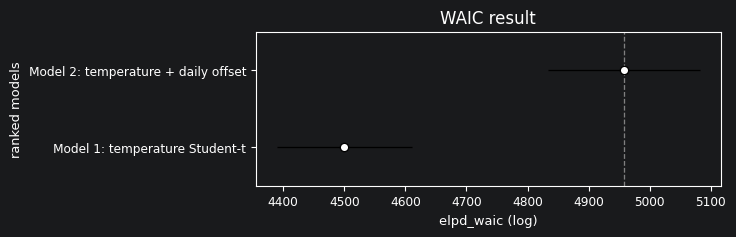

In [5]:
comp_waic = az.compare(idatas, ic="waic", scale="log")
display(comp_waic)

az.plot_compare(comp_waic)
plt.title("WAIC result")
plt.show()

WAIC ranks Model 2 first. Its expected log predictive density is higher than for Model 1 (`elpd_waic` = 4957.68 vs 4499.96), with an elpd difference of 457.71 and standard error of the difference equal to 28.02. The difference is much larger than its uncertainty, so the comparison does not show meaningful overlap and clearly favors Model 2. There are no WAIC warnings for either model.

## PSIS-LOO

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2: temperature + daily offset,0,4957.611342,43.325948,0.000000,0.992788,123.854287,0.000000,False,log
Model 1: temperature Student-t,1,4499.958398,3.767821,457.652944,0.007212,110.207380,28.022447,False,log


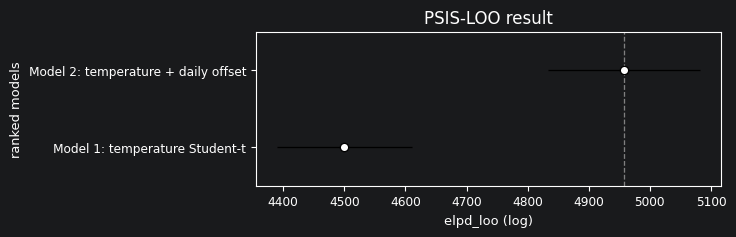

In [6]:
comp_loo = az.compare(idatas, ic="loo", scale="log")
display(comp_loo)

az.plot_compare(comp_loo)
plt.title("PSIS-LOO result")
plt.show()

PSIS-LOO gives the same conclusion as WAIC. Model 2 has a higher expected log predictive density than Model 1 (`elpd_loo` = 4957.61 vs 4499.96), with an elpd difference of 457.65 and standard error of the difference equal to 28.02. The difference is large relative to the uncertainty, so PSIS-LOO also clearly favors Model 2. There are no PSIS-LOO warnings for either model.

## Final assessment

Both information criteria agree that Model 2 has better predictive performance than Model 1. We agree with this selection because Model 2 includes day-level variation, which captures systematic differences between days that cannot be explained by temperature alone. Although Model 2 is more complex, the improvement in predictive accuracy is large and there are no WAIC or PSIS-LOO warnings, so the additional complexity is justified.